In [14]:
# EX 1

import csv
import random

nume_fisier = input("Numele fisierului: ")
nr_studenti = int(input("Numarul de studenti alesi: "))

with open(nume_fisier, newline="", encoding="utf-8") as fisier:
  cititor = csv.reader(fisier)
  next(cititor)
  studenti = []

  for linie in cititor:
    if len(linie) > 0:
       studenti.append(linie[0])

if nr_studenti > len(studenti):
  print("Nu poti alege mai multi studenti decat exista in lista")
else:
  alesi = random.sample(studenti, nr_studenti)
  print("Studentii alesi sunt: ")
  for student in alesi:
    print(student)

Numele fisierului: studenti.csv
Numarul de studenti alesi: 3
Studentii alesi sunt: 
Vlad Marinescu
Elena Dumitru
Ion Georgescu


EX 2

a) Jocul se opreste la prima aparitie a stemei, prin urmare, N este numarul de aruncari pana la prima stema. N urmeaza o distributie geometrica, urmarind cate incercari sunt pana la primul succes.



In [17]:
# b)

import numpy as np

def simulare (p_stema=0.5):
  N = 0
  S = 0

  while True:
    N = N + 1
    moneda = np.random.choice(
        ["stema", "ban"],
        p=[p_stema, 1 - p_stema]
    )

    if moneda == "stema":
       zar = np.random.randint(1,7)
       S = S + zar - 3
       break

    else:
      S = S - 0.5

  return N, S

In [30]:
N, S = simulare()
print("N = ", N)
print("S = ", S)


N =  4
S =  -2.5


Media lui S =  -0.0309


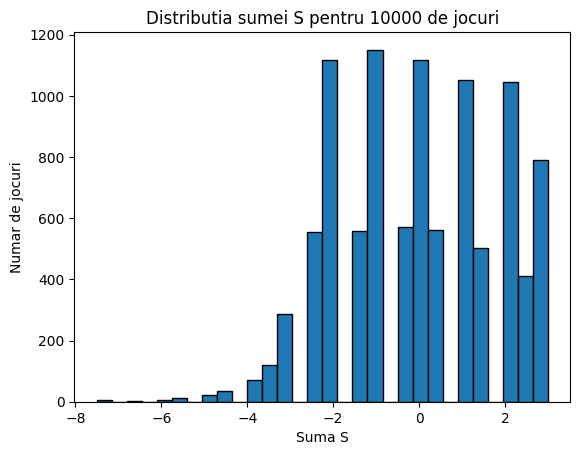

In [36]:
# c)

import matplotlib.pyplot as plt

nr_jocuri = 10000
valori_S = []

for i in range(nr_jocuri):
  N, S = simulare()
  valori_S.append(S)

media_S = np.mean(valori_S)

print("Media lui S = ", media_S)

plt.hist(valori_S, bins=30, edgecolor="black")

plt.xlabel("Suma S")
plt.ylabel("Numar de jocuri")
plt.title("Distributia sumei S pentru 10000 de jocuri")

plt.show()

Pentru p = 0.3
Media lui S este: -0.6433


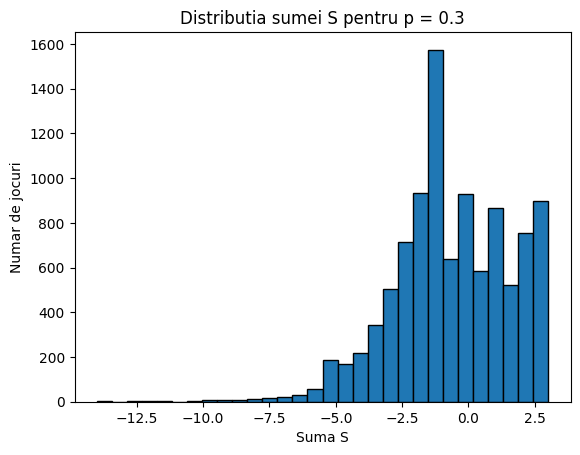

Pentru p = 0.7
Media lui S este: 0.2744


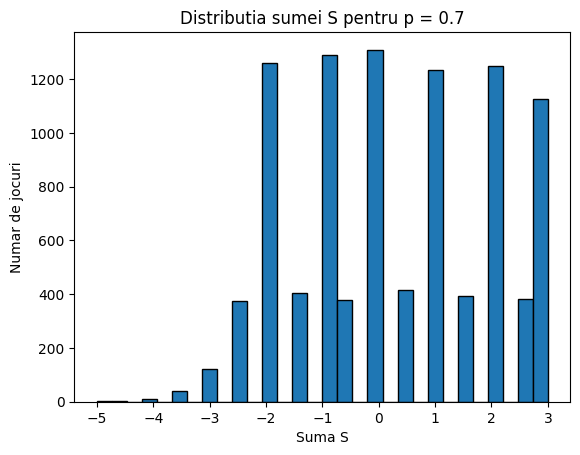

In [46]:
# d)

for p_stema in [0.3, 0.7]:
    valori_S = []

    for i in range(10000):
      N, S = simulare(p_stema)
      valori_S.append(S)

    media_S = np.mean(valori_S)

    print("Pentru p =", p_stema)
    print("Media lui S este:", media_S)

    plt.hist(valori_S, bins=30, edgecolor="black")

    plt.xlabel("Suma S")
    plt.ylabel("Numar de jocuri")
    plt.title("Distributia sumei S pentru p = " + str(p_stema))

    plt.show()


Media estimata: 0.2301219269307759 ore
Deviatia standard estimata: 0.24930658797254404 ore


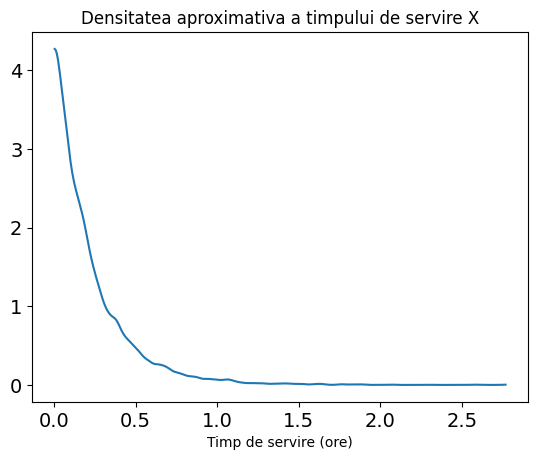

In [45]:
# EX 3

import arviz as az

viteze = [3, 6, 4]

prob = [
    3 / 13,
    6 / 13,
    4 / 13
]

timpi = []

for i in range(10000):
    frizer = np.random.choice(
        [0, 1, 2],
        p=prob
    )

    timp = np.random.exponential(
        scale=1 / viteze[frizer]
    )

    timpi.append(timp)

print("Media estimata:", np.mean(timpi), "ore")
print("Deviatia standard estimata:", np.std(timpi), "ore")

az.plot_kde(np.array(timpi))

plt.xlabel("Timp de servire (ore)")
plt.title("Densitatea aproximativa a timpului de servire X")

plt.show()